# Learn FF Connectivity — Analysis

Analyse the 3-phase training run: CMA-ES → gradient scaling factors → low-rank FF weights + scaling.
Feedforward inputs are actual mitral cell spike trains; the FF weight matrix is learned via a U @ V low-rank decomposition.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import toml
import torch
import zarr
from scipy.stats import mannwhitneyu, pearsonr
from tqdm.auto import tqdm

from connectome_snns.utils.reproducibility import load_experiment_config
from connectome_snns.visualization import (
    use_project_style,
    EXCITATORY_COLOR,
    INHIBITORY_COLOR,
    TEACHER_COLOR,
    STUDENT_COLOR,
    plot_firing_rate_scatter,
    plot_r2_comparison_bar,
    plot_spike_trains,
    plot_sf_bar_chart,
)
from connectome_snns.visualization.scaling_factors import SF_PATHWAYS, plot_sf_trajectories
from connectome_snns.analysis import (
    r_squared,
    fluctuation_r_squared,
    firing_rates_from_spikes,
    interleave_spike_trains,
)
from connectome_snns.analysis.inference import run_feedforward_inference
from connectome_snns.analysis import ensure_test_inputs
from connectome_snns.analysis.firing_statistics import compute_spike_train_cv
from connectome_snns.analysis.voltage_statistics import compute_membrane_potential_by_cell_type
from connectome_snns.configs import StudentSimulationConfig, StudentHyperparameters
from connectome_snns.configs.conductance_based import RecurrentLayerConfig, FeedforwardLayerConfig
from connectome_snns.network_simulators.feedforward_conductance_based.simulator import (
    FeedforwardConductanceLIFNetwork,
)
from connectome_snns.network_simulators.projections import make_frozen_chunked_ff_projections

use_project_style()

In [2]:
config = load_experiment_config("experiment.toml")
RESULTS_DIR = config["output_dir"]
PARAMS_FILE = config["parameters_file"]

MAX_RATE = 40
TICKS = np.arange(0, MAX_RATE + 10, 10)
TAU_MS = 50.0
N_NEURONS_RASTER = 10
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

CELL_TYPE_COLORS = {0: EXCITATORY_COLOR, 1: INHIBITORY_COLOR}

In [ ]:
# Generate (or load cached) teacher test activity: same network as training,
# but batch_size=1 and seed+10 for an unseen rollout. Cached as a zarr in the run dir.
TEST_ZARR_PATH = ensure_test_inputs(RESULTS_DIR, device=DEVICE)

In [ ]:
RUN_DIR = RESULTS_DIR

df = pd.read_csv(RUN_DIR / "training_metrics.csv")
print(f"Run: {RUN_DIR}")
print(f"  {len(df)} logged steps")

# Network structures (same teacher network in training and test)
ns_init = np.load(RUN_DIR / "initial_state" / "network_structure.npz")
ns_final = np.load(RUN_DIR / "final_state" / "network_structure.npz")
ns_teacher = np.load(RUN_DIR / "inputs" / "network_structure.npz")
cell_type_indices = ns_final["cell_type_indices"]
assembly_ids = ns_teacher["assembly_ids"]
n_neurons = len(cell_type_indices)

# Test spike data
zarr_root = zarr.open_group(TEST_ZARR_PATH, mode="r")
dt = float(zarr_root.attrs["dt"])
n_feedforward = zarr_root["input_spikes"].shape[2]

# Training parameters
params = toml.load(PARAMS_FILE)
ff_rank = params["hyperparameters"].get("ff_rank", 10)

# Inference window: burn-in from training params, analysis = rest of test data
_chunk_size = params["simulation"]["chunk_size"]
_test_total_chunks = zarr_root["input_spikes"].shape[1] // _chunk_size
N_BURNIN_CHUNKS = int(params["training"]["burn_in_chunks"])
N_ANALYSIS_CHUNKS = _test_total_chunks - N_BURNIN_CHUNKS

print(f"  {n_neurons} neurons, {n_feedforward} mitral inputs, dt={dt} ms")
print(f"  FF rank constraint: {ff_rank}")
print(f"  {len(np.unique(assembly_ids))} assemblies")
print(
    f"  Test inference: {N_BURNIN_CHUNKS} burnin + {N_ANALYSIS_CHUNKS} analysis chunks "
    f"({N_BURNIN_CHUNKS * _chunk_size * dt / 1000:.1f}s + {N_ANALYSIS_CHUNKS * _chunk_size * dt / 1000:.1f}s)"
)

# Target scaling factors
targets = np.load(RUN_DIR / "targets" / "target_scaling_factors.npz")
target_sf_rec = targets["recurrent_scaling_factors"]  # (2, 2)

# Phase split
cma_rows = df[df["epoch"] < 0]
gradient_rows = df[df["epoch"] >= 0]
print(f"  CMA-ES: {len(cma_rows)} logged generations")
print(f"  Gradient: {len(gradient_rows)} logged steps")

## Training Curves

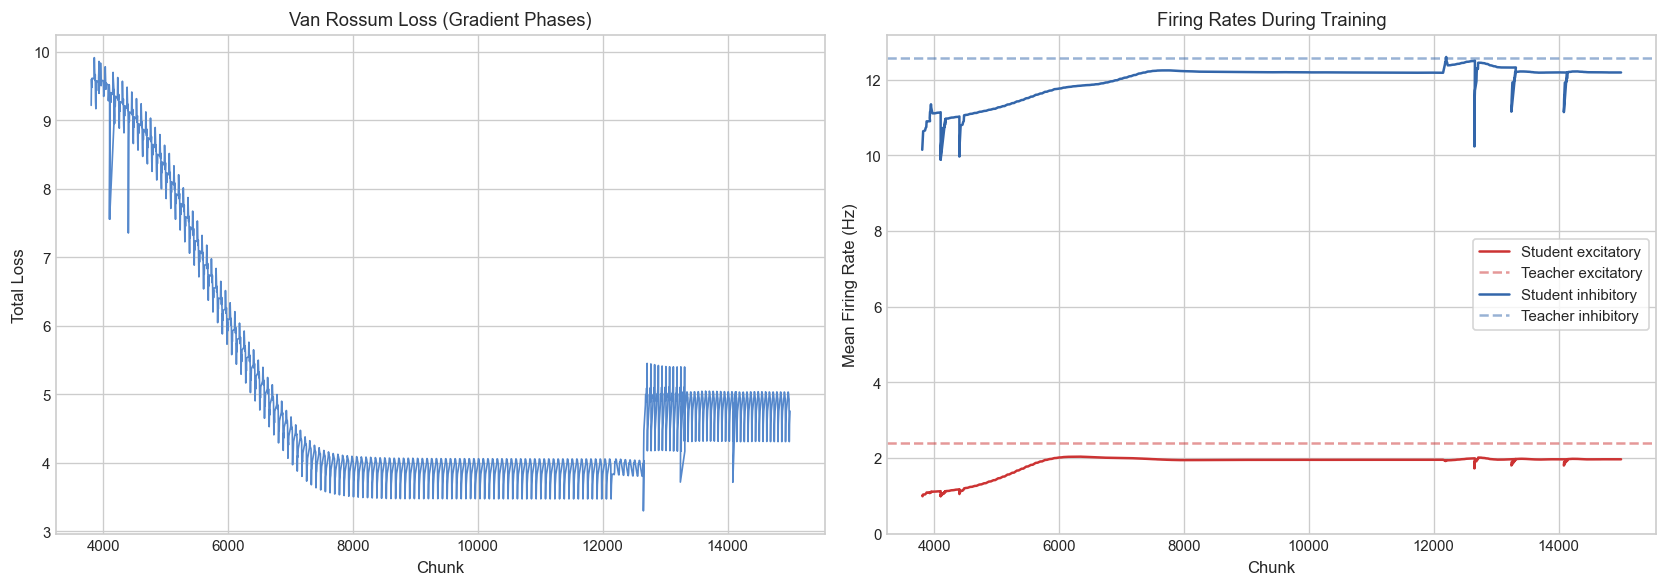

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: loss over gradient phase
ax = axes[0]
grad = gradient_rows
ax.plot(grad["epoch"], grad["total_loss"], color=STUDENT_COLOR, linewidth=1)
ax.set_xlabel("Chunk")
ax.set_ylabel("Total Loss")
ax.set_title("Van Rossum Loss (Gradient Phases)")

# Right: firing rates over gradient phase
ax = axes[1]
for ct_label, color in [
    ("excitatory", EXCITATORY_COLOR),
    ("inhibitory", INHIBITORY_COLOR),
]:
    col = f"firing_rate/student_{ct_label}_mean"
    teacher_col = f"firing_rate/teacher_{ct_label}_mean"
    if col in grad.columns:
        ax.plot(grad["epoch"], grad[col], color=color, label=f"Student {ct_label}")
    if teacher_col in grad.columns:
        ax.axhline(
            grad[teacher_col].dropna().iloc[-1],
            color=color,
            linewidth=1.5,
            linestyle="--",
            alpha=0.5,
            label=f"Teacher {ct_label}",
        )

ax.set_xlabel("Chunk")
ax.set_ylabel("Mean Firing Rate (Hz)")
ax.set_title("Firing Rates During Training")
ax.set_ylim(0, None)
ax.legend(frameon=True, fontsize=9)

plt.tight_layout()
plt.show()

## Scaling Factor Recovery

Available SF pathways: ['excitatory_to_excitatory', 'excitatory_to_inhibitory', 'inhibitory_to_excitatory', 'inhibitory_to_inhibitory']


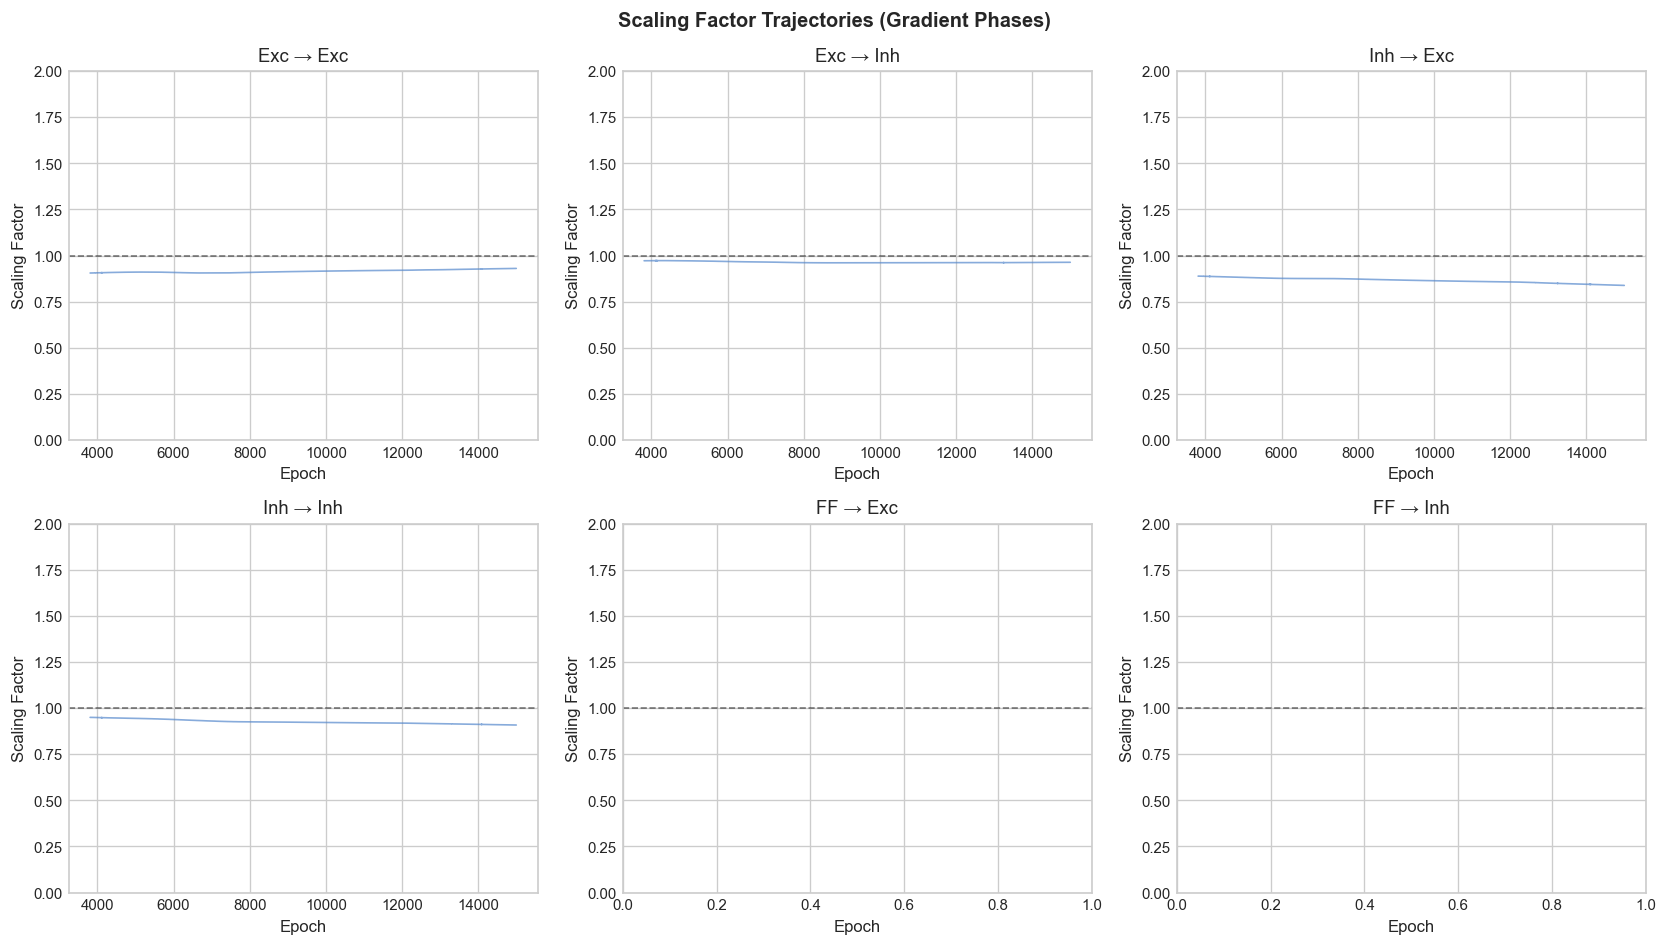

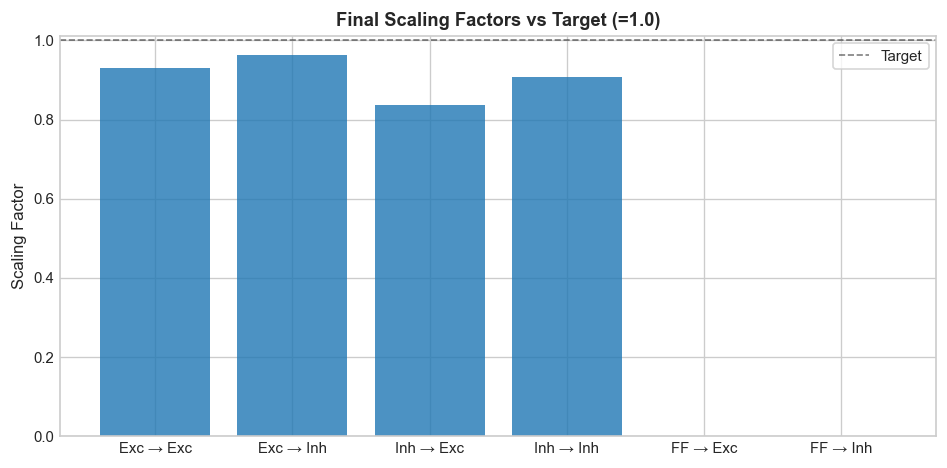


Final recurrent scaling factors (normalised to target):
  Exc → Exc                       0.9300
  Exc → Inh                       0.9632
  Inh → Exc                       0.8379
  Inh → Inh                       0.9078


In [6]:
# Scaling factor trajectories over gradient phase
sf_keys = [key for key, _ in SF_PATHWAYS]

available_sf_keys = [
    k for k in sf_keys if f"scaling_factors/{k}_value" in gradient_rows.columns
]
print(f"Available SF pathways: {available_sf_keys}")

# Trajectories
runs_df_dict = {"run": gradient_rows}
plot_sf_trajectories(
    runs_df_dict,
    colors={"run": STUDENT_COLOR},
    label_fn=lambda k: "Student",
    suptitle="Scaling Factor Trajectories (Gradient Phases)",
)
plt.show()

# Final values as bar chart
final_row = gradient_rows.iloc[-1]
sf_final = {
    key: float(final_row[f"scaling_factors/{key}_value"]) for key in available_sf_keys
}

plot_sf_bar_chart(
    sf_final,
    figsize=(8, 4),
    title="Final Scaling Factors vs Target (=1.0)",
)
plt.show()

# Print final values
print("\nFinal recurrent scaling factors (normalised to target):")
for key in available_sf_keys:
    label = dict(SF_PATHWAYS).get(key, key)
    print(f"  {label:<30s}  {sf_final[key]:.4f}")

## Learned FF Weight Matrix

The FF weight matrix is learned from scratch with a low-rank (U @ V) parametrisation.
Unlike the latent-input experiment, here we have 1500 mitral inputs (same as teacher)
so we can directly compare learned weights to the teacher's true FF weights.

Learned FF weight matrix statistics:
  Shape: (1500, 5000)
  Mean:  0.001390
  Std:   0.000971
  Min:   0.000033
  Max:   0.042099
  → Excitatory: mean=0.001624, std=0.000904
  → Inhibitory: mean=0.000455, std=0.000597

Teacher FF weight matrix:
  Shape: (1500, 5000)
  Mean:  0.001293
  Std:   0.039981


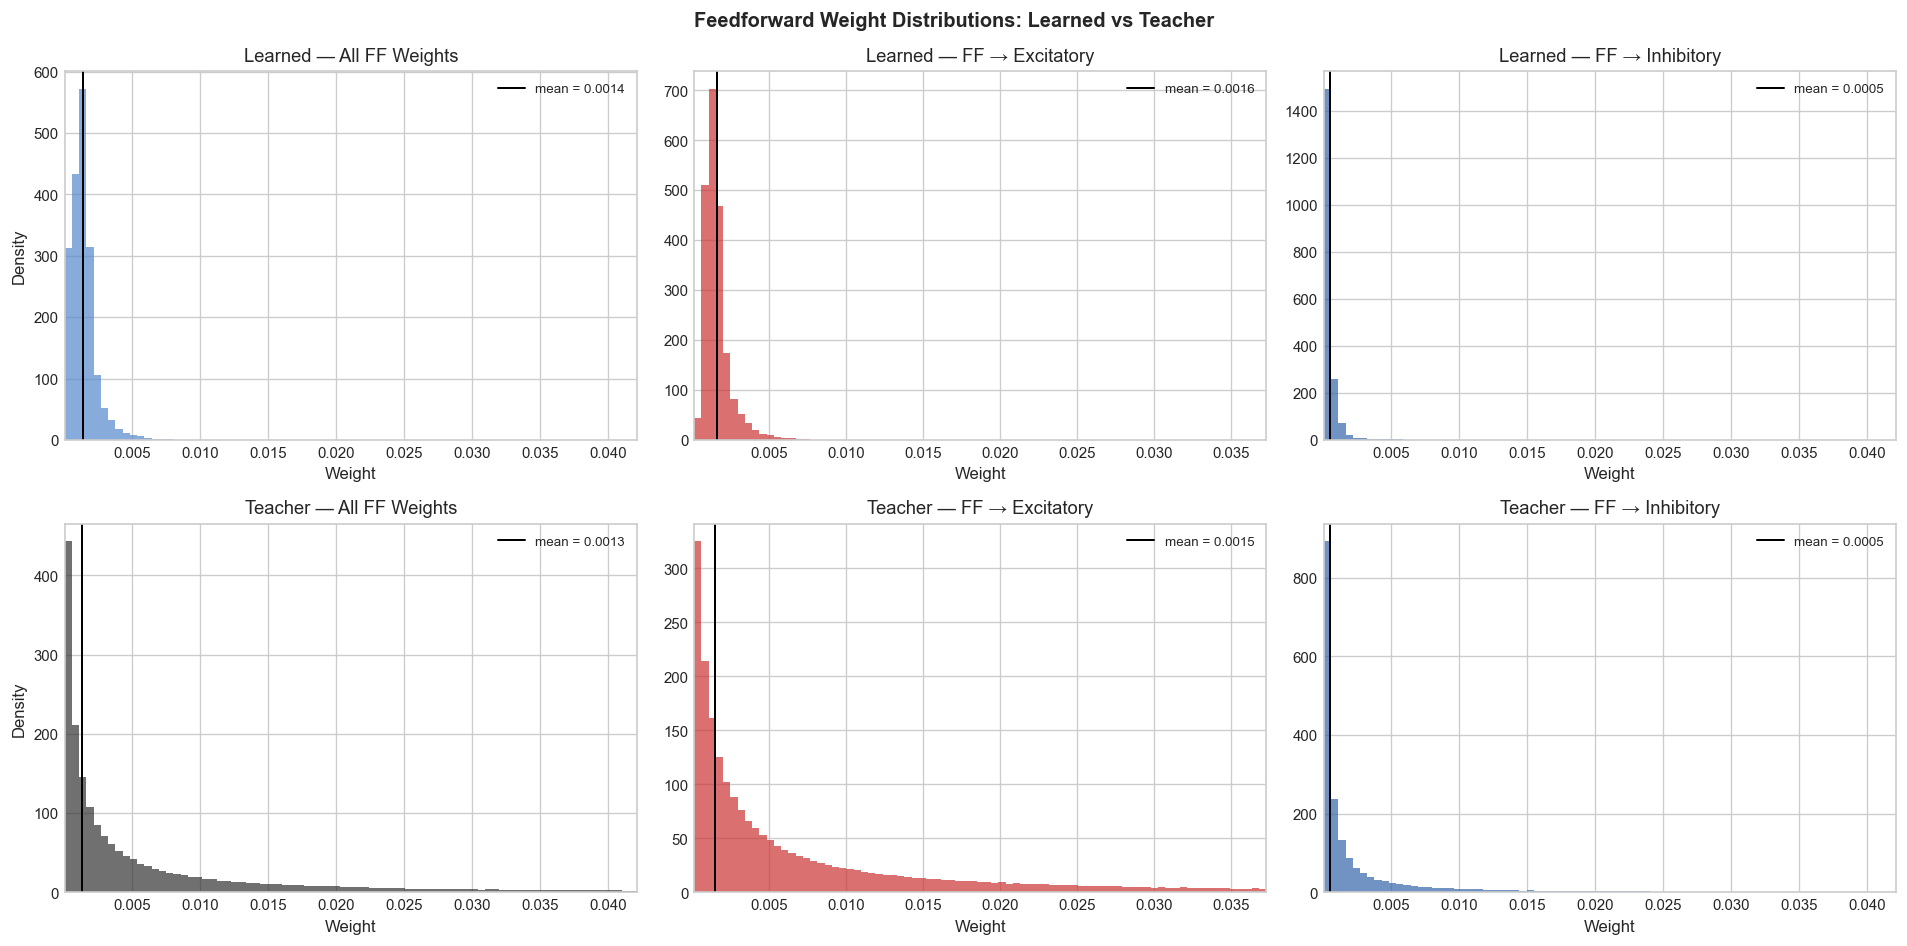

In [7]:
# Final state has SF baked into weights
final_weights = ns_final["feedforward_weights"]
learned_ff_w = final_weights[:n_feedforward, :]  # (n_feedforward, n_neurons)
rec_w = final_weights[n_feedforward:, :]  # (n_neurons, n_neurons)

teacher_ff_w = ns_teacher["feedforward_weights"]  # (n_feedforward, n_neurons)

exc_mask = cell_type_indices == 0
inh_mask = cell_type_indices == 1

print("Learned FF weight matrix statistics:")
print(f"  Shape: {learned_ff_w.shape}")
print(f"  Mean:  {learned_ff_w.mean():.6f}")
print(f"  Std:   {learned_ff_w.std():.6f}")
print(f"  Min:   {learned_ff_w.min():.6f}")
print(f"  Max:   {learned_ff_w.max():.6f}")
print(
    f"  → Excitatory: mean={learned_ff_w[:, exc_mask].mean():.6f}, "
    f"std={learned_ff_w[:, exc_mask].std():.6f}"
)
print(
    f"  → Inhibitory: mean={learned_ff_w[:, inh_mask].mean():.6f}, "
    f"std={learned_ff_w[:, inh_mask].std():.6f}"
)

print("\nTeacher FF weight matrix:")
print(f"  Shape: {teacher_ff_w.shape}")
print(f"  Mean:  {teacher_ff_w.mean():.6f}")
print(f"  Std:   {teacher_ff_w.std():.6f}")

# Weight distributions: histograms per output cell type
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

# x-axis pinned to the learned-weight range (per column)
col_data = [
    learned_ff_w.ravel(),
    learned_ff_w[:, exc_mask].ravel(),
    learned_ff_w[:, inh_mask].ravel(),
]
col_xlims = [(d.min(), d.max()) for d in col_data]

for row, (label, w) in enumerate(
    [("Learned", learned_ff_w), ("Teacher", teacher_ff_w)]
):
    color = STUDENT_COLOR if row == 0 else TEACHER_COLOR

    panels = [
        (axes[row, 0], w.ravel(), color, f"{label} — All FF Weights"),
        (
            axes[row, 1],
            w[:, exc_mask].ravel(),
            EXCITATORY_COLOR,
            f"{label} — FF → Excitatory",
        ),
        (
            axes[row, 2],
            w[:, inh_mask].ravel(),
            INHIBITORY_COLOR,
            f"{label} — FF → Inhibitory",
        ),
    ]
    for col, (ax, vals, c, title) in enumerate(panels):
        lo, hi = col_xlims[col]
        bins = np.linspace(lo, hi, 80)
        ax.hist(vals, bins=bins, color=c, alpha=0.7, density=True)
        ax.set_xlim(lo, hi)
        ax.set_xlabel("Weight")
        ax.set_title(title)
        ax.axvline(0, color="k", linewidth=0.5, linestyle="--")
        mean = vals.mean()
        ax.axvline(
            mean, color="k", linewidth=1.2, linestyle="-", label=f"mean = {mean:.4f}"
        )
        ax.legend(fontsize=8, loc="upper right")
        if col == 0:
            ax.set_ylabel("Density")

plt.suptitle("Feedforward Weight Distributions: Learned vs Teacher", fontweight="bold")
plt.tight_layout()
plt.show()

## FF Weight Correlation with Teacher

Element-wise correlation: learned vs teacher FF weights
  All:         r=0.0330, p=0.00e+00
  Excitatory:  r=0.0265, p=0.00e+00
  Inhibitory:  r=0.0720, p=0.00e+00

Per-neuron total FF input correlation:
  Excitatory:  r=0.9174
  Inhibitory:  r=0.9221


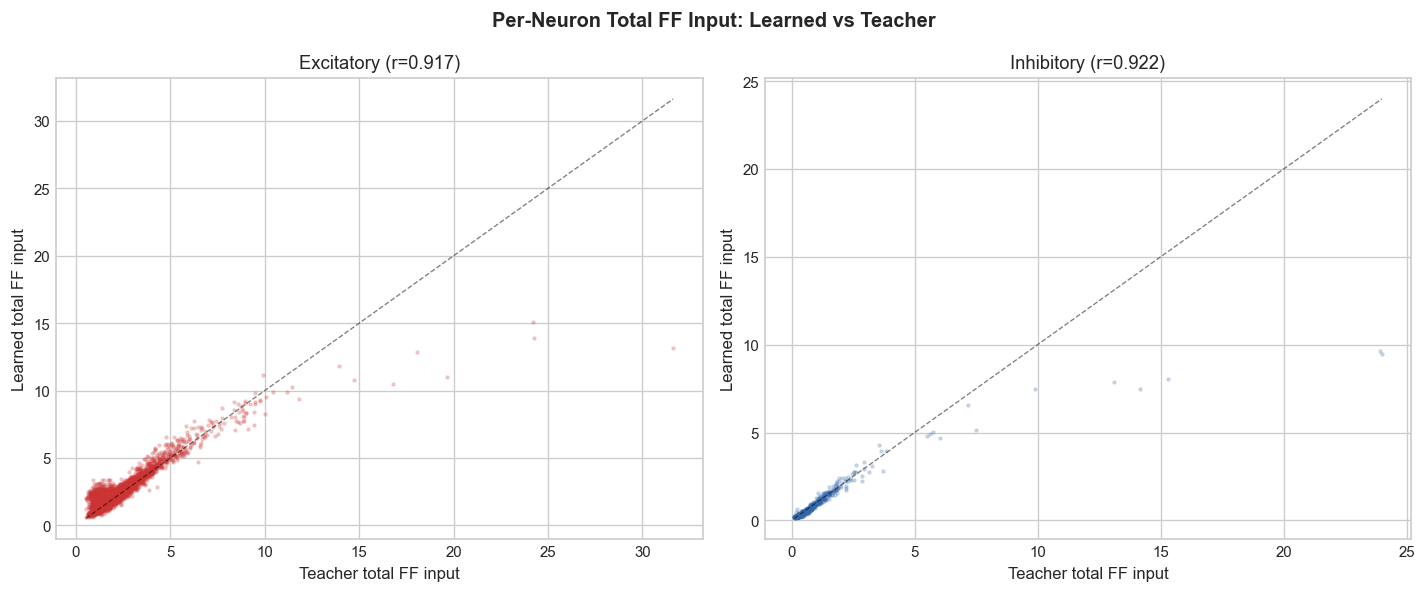

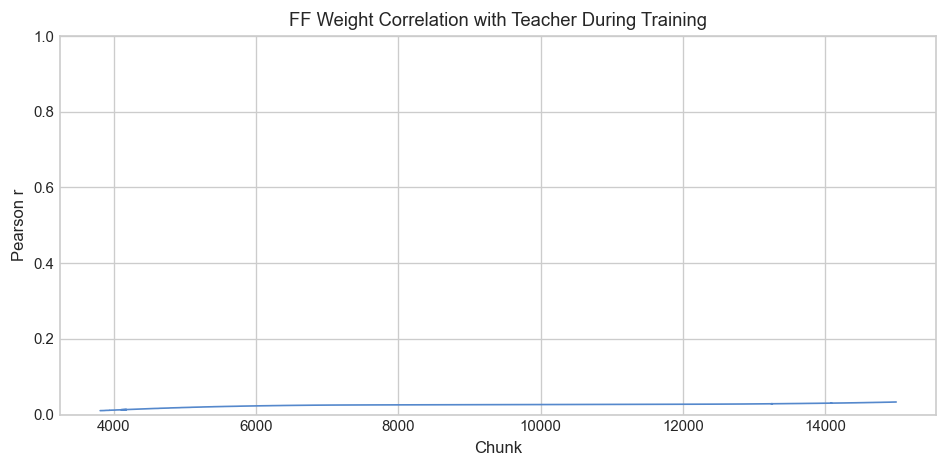

In [8]:
# Element-wise correlation between learned and teacher FF weights
r_all, p_all = pearsonr(learned_ff_w.ravel(), teacher_ff_w.ravel())
r_exc, p_exc = pearsonr(
    learned_ff_w[:, exc_mask].ravel(), teacher_ff_w[:, exc_mask].ravel()
)
r_inh, p_inh = pearsonr(
    learned_ff_w[:, inh_mask].ravel(), teacher_ff_w[:, inh_mask].ravel()
)

print("Element-wise correlation: learned vs teacher FF weights")
print(f"  All:         r={r_all:.4f}, p={p_all:.2e}")
print(f"  Excitatory:  r={r_exc:.4f}, p={p_exc:.2e}")
print(f"  Inhibitory:  r={r_inh:.4f}, p={p_inh:.2e}")

# Per-neuron total FF input correlation
learned_total_ff = learned_ff_w.sum(axis=0)
teacher_total_ff = teacher_ff_w.sum(axis=0)

r_total_exc, _ = pearsonr(learned_total_ff[exc_mask], teacher_total_ff[exc_mask])
r_total_inh, _ = pearsonr(learned_total_ff[inh_mask], teacher_total_ff[inh_mask])
print("\nPer-neuron total FF input correlation:")
print(f"  Excitatory:  r={r_total_exc:.4f}")
print(f"  Inhibitory:  r={r_total_inh:.4f}")

# Scatter: learned vs teacher total FF input per neuron
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.scatter(
    teacher_total_ff[exc_mask],
    learned_total_ff[exc_mask],
    s=3,
    alpha=0.2,
    color=EXCITATORY_COLOR,
    rasterized=True,
)
lims = [
    min(teacher_total_ff[exc_mask].min(), learned_total_ff[exc_mask].min()),
    max(teacher_total_ff[exc_mask].max(), learned_total_ff[exc_mask].max()),
]
ax.plot(lims, lims, "k--", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Teacher total FF input")
ax.set_ylabel("Learned total FF input")
ax.set_title(f"Excitatory (r={r_total_exc:.3f})")

ax = axes[1]
ax.scatter(
    teacher_total_ff[inh_mask],
    learned_total_ff[inh_mask],
    s=3,
    alpha=0.2,
    color=INHIBITORY_COLOR,
    rasterized=True,
)
lims = [
    min(teacher_total_ff[inh_mask].min(), learned_total_ff[inh_mask].min()),
    max(teacher_total_ff[inh_mask].max(), learned_total_ff[inh_mask].max()),
]
ax.plot(lims, lims, "k--", linewidth=0.8, alpha=0.5)
ax.set_xlabel("Teacher total FF input")
ax.set_ylabel("Learned total FF input")
ax.set_title(f"Inhibitory (r={r_total_inh:.3f})")

plt.suptitle(
    "Per-Neuron Total FF Input: Learned vs Teacher",
    fontweight="bold",
)
plt.tight_layout()
plt.show()

# Correlation trajectory during training
if "ff_weights/teacher_correlation" in gradient_rows.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(
        gradient_rows["epoch"],
        gradient_rows["ff_weights/teacher_correlation"],
        color=STUDENT_COLOR,
        linewidth=1,
    )
    ax.set_xlabel("Chunk")
    ax.set_ylabel("Pearson r")
    ax.set_title("FF Weight Correlation with Teacher During Training")
    ax.set_ylim(0, 1)
    plt.tight_layout()
    plt.show()

## Effective Rank and SVD Spectrum

Effective rank (participation ratio):
  Learned: 1.10
  Teacher: 656.81
  Low-rank constraint: 10

Variance explained by top-10 components:
  Learned: 1.0000
  Teacher: 0.3488


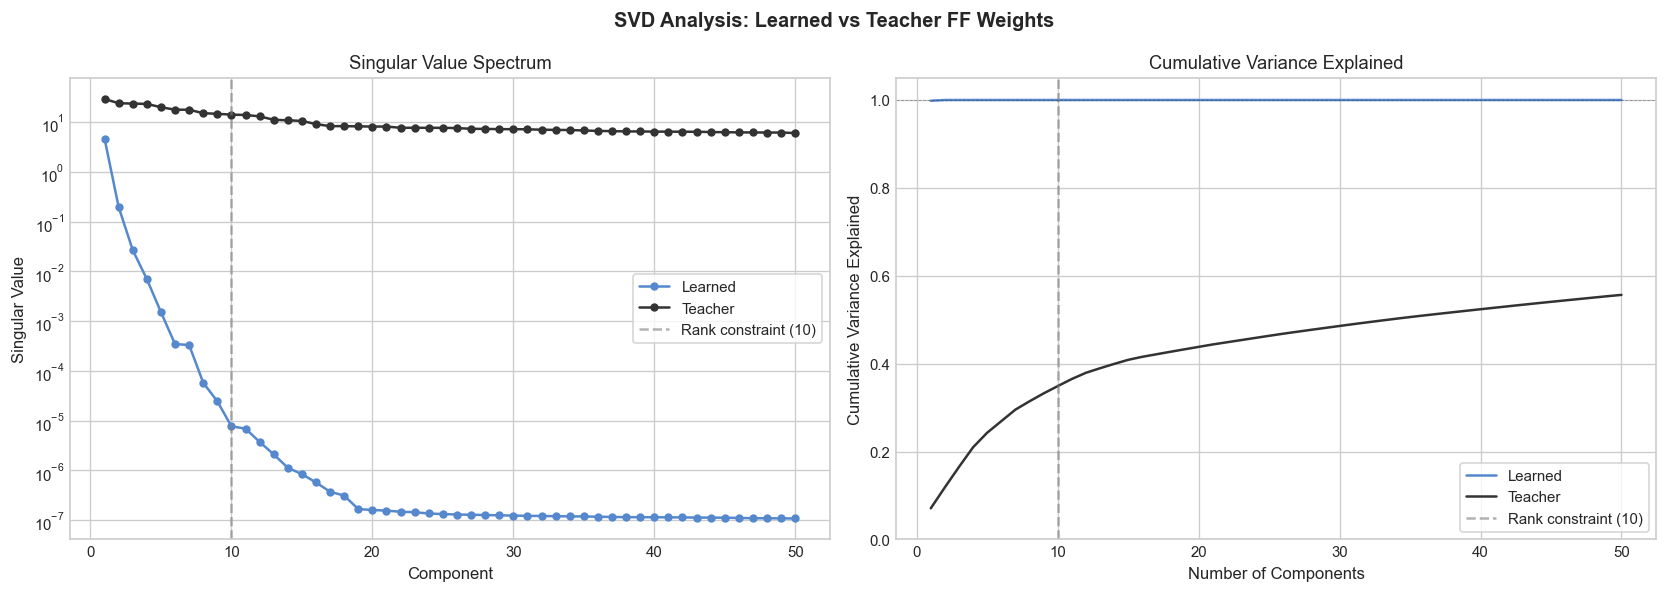

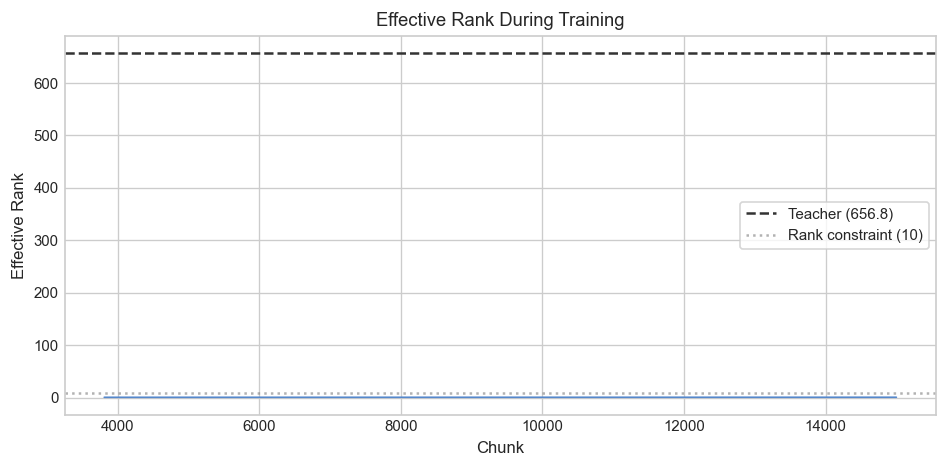

In [9]:
# SVD of learned and teacher FF weight matrices
s_learned = np.linalg.svd(learned_ff_w, compute_uv=False)
s_teacher = np.linalg.svd(teacher_ff_w, compute_uv=False)

# Participation ratio (effective rank)
eff_rank_learned = (s_learned.sum() ** 2) / (s_learned**2).sum()
eff_rank_teacher = (s_teacher.sum() ** 2) / (s_teacher**2).sum()

print("Effective rank (participation ratio):")
print(f"  Learned: {eff_rank_learned:.2f}")
print(f"  Teacher: {eff_rank_teacher:.2f}")
print(f"  Low-rank constraint: {ff_rank}")

# Variance explained by top-k components
var_learned = (s_learned**2) / (s_learned**2).sum()
var_teacher = (s_teacher**2) / (s_teacher**2).sum()
cum_var_learned = np.cumsum(var_learned)
cum_var_teacher = np.cumsum(var_teacher)

print(f"\nVariance explained by top-{ff_rank} components:")
print(f"  Learned: {cum_var_learned[ff_rank - 1]:.4f}")
print(f"  Teacher: {cum_var_teacher[ff_rank - 1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: singular value spectrum
n_show = min(50, len(s_learned))
ax = axes[0]
ax.plot(
    range(1, n_show + 1),
    s_learned[:n_show],
    "o-",
    color=STUDENT_COLOR,
    markersize=4,
    label="Learned",
)
ax.plot(
    range(1, n_show + 1),
    s_teacher[:n_show],
    "o-",
    color=TEACHER_COLOR,
    markersize=4,
    label="Teacher",
)
ax.axvline(
    ff_rank,
    color="grey",
    linestyle="--",
    alpha=0.6,
    label=f"Rank constraint ({ff_rank})",
)
ax.set_xlabel("Component")
ax.set_ylabel("Singular Value")
ax.set_title("Singular Value Spectrum")
ax.legend(frameon=True, fontsize=9)
ax.set_yscale("log")

# Right: cumulative variance explained
ax = axes[1]
ax.plot(
    range(1, n_show + 1),
    cum_var_learned[:n_show],
    "-",
    color=STUDENT_COLOR,
    label="Learned",
)
ax.plot(
    range(1, n_show + 1),
    cum_var_teacher[:n_show],
    "-",
    color=TEACHER_COLOR,
    label="Teacher",
)
ax.axvline(
    ff_rank,
    color="grey",
    linestyle="--",
    alpha=0.6,
    label=f"Rank constraint ({ff_rank})",
)
ax.axhline(1.0, color="k", linewidth=0.5, linestyle="--", alpha=0.3)
ax.set_xlabel("Number of Components")
ax.set_ylabel("Cumulative Variance Explained")
ax.set_title("Cumulative Variance Explained")
ax.legend(frameon=True, fontsize=9)
ax.set_ylim(0, 1.05)

plt.suptitle("SVD Analysis: Learned vs Teacher FF Weights", fontweight="bold")
plt.tight_layout()
plt.show()

# Effective rank trajectory during training
if "ff_weights/effective_rank" in gradient_rows.columns:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(
        gradient_rows["epoch"],
        gradient_rows["ff_weights/effective_rank"],
        color=STUDENT_COLOR,
        linewidth=1,
    )
    ax.axhline(
        eff_rank_teacher,
        color=TEACHER_COLOR,
        linestyle="--",
        linewidth=1.5,
        label=f"Teacher ({eff_rank_teacher:.1f})",
    )
    ax.axhline(
        ff_rank,
        color="grey",
        linestyle=":",
        alpha=0.6,
        label=f"Rank constraint ({ff_rank})",
    )
    ax.set_xlabel("Chunk")
    ax.set_ylabel("Effective Rank")
    ax.set_title("Effective Rank During Training")
    ax.legend(frameon=True, fontsize=9)
    plt.tight_layout()
    plt.show()

## Assembly Specificity

In [10]:
# Compare assembly specificity of learned vs teacher FF weights.
# For each mitral cell, compare total weight to its own assembly vs other assemblies.
# Mitral cells have assembly_ids defined in the teacher network.
n_assemblies = len(np.unique(assembly_ids))

# Mitral cell assembly IDs (from teacher)
mitral_assembly_ids = ns_teacher.get("feedforward_assembly_ids", None)
if mitral_assembly_ids is None:
    # Fall back: check latent assignments or use assembly_ids for output neurons
    mitral_assembly_ids = None

# Assembly-level analysis: sum of weights from each mitral to each target assembly
# Aggregate at the assembly level for both learned and teacher
for w_label, w_matrix in [("Learned", learned_ff_w), ("Teacher", teacher_ff_w)]:
    groups = {}
    for ct_label, ct_mask in [("E", exc_mask), ("I", inh_mask)]:
        same, diff = [], []
        # Per-assembly: sum weights from all mitral cells to neurons in each assembly
        for a in range(n_assemblies):
            assembly_mask = (assembly_ids == a) & ct_mask
            total_w = w_matrix[:, assembly_mask].sum()
            # Compare to other assemblies
            other_mask = (assembly_ids != a) & ct_mask
            other_w = w_matrix[:, other_mask].sum() / max(n_assemblies - 1, 1)
            same.append(total_w)
            diff.append(other_w)
        groups[f"{ct_label} same"] = np.array(same)
        groups[f"{ct_label} other"] = np.array(diff)

    print(f"\n{w_label} — Assembly-level total weight:")
    for ct_label in ["E", "I"]:
        same = groups[f"{ct_label} same"]
        other = groups[f"{ct_label} other"]
        stat, pval = mannwhitneyu(same, other, alternative="two-sided")
        d = (same.mean() - other.mean()) / np.sqrt(
            (same.std() ** 2 + other.std() ** 2) / 2
        )
        print(
            f"  {ct_label}: same={same.mean():.2f}, other={other.mean():.2f}, "
            f"d={d:.3f}, p={pval:.2e}"
        )


Learned — Assembly-level total weight:
  E: same=487.24, other=487.24, d=0.000, p=8.82e-01
  I: same=34.15, other=34.15, d=-0.000, p=5.79e-01

Teacher — Assembly-level total weight:
  E: same=446.07, other=446.07, d=-0.000, p=7.97e-01
  I: same=38.67, other=38.67, d=-0.000, p=2.85e-01


## Inference: Firing Rates and Fluctuation R²

In [ ]:
# Run inference with the trained model on the held-out test rollout
# FF input = mitral spikes from the cached test zarr
cache_path = RUN_DIR / "final_state" / "inference_cache_test.npz"

# Final state has SF baked in (all 1.0)
scaling_factors_FF = ns_final["scaling_factors_FF"]

data = run_feedforward_inference(
    params_file=PARAMS_FILE,
    run_dir=RUN_DIR,
    zarr_subpath=str(TEST_ZARR_PATH),
    scaling_factors_FF=scaling_factors_FF,
    network_structure_path=RUN_DIR / "final_state" / "network_structure.npz",
    n_burnin_chunks=N_BURNIN_CHUNKS,
    n_analysis_chunks=N_ANALYSIS_CHUNKS,
    cache_path=cache_path,
    device=DEVICE,
    desc="ff-connectivity inference (test)",
)

teacher_spikes = data["teacher_spikes"]
student_spikes = data["student_spikes"]
ct = data["cell_type_indices"]
inf_dt = float(data["dt"])

duration_s = teacher_spikes.shape[0] * inf_dt / 1000.0
print(f"Inference: {duration_s:.1f}s of data, {teacher_spikes.shape[1]} neurons")

Activity R²:     0.8921
Fluctuation R²:  0.8256


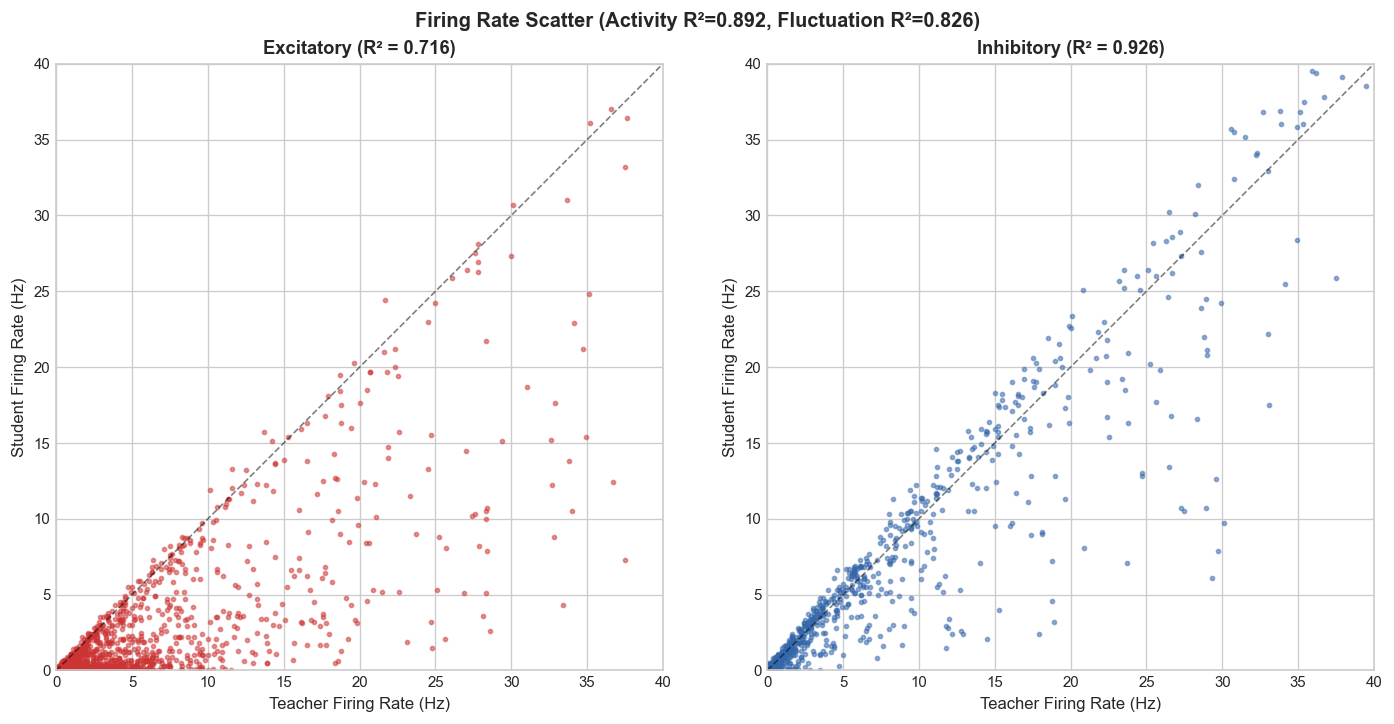

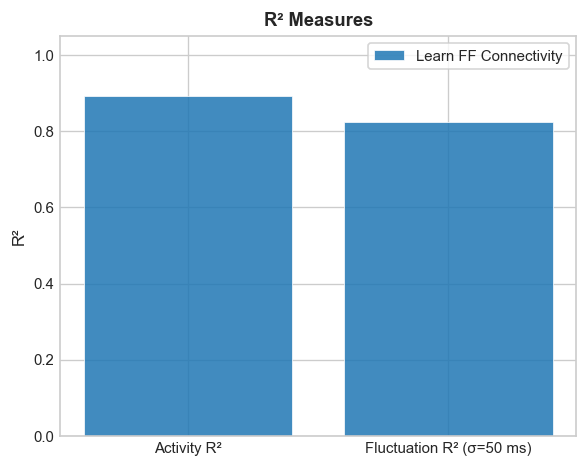

In [12]:
teacher_fr = firing_rates_from_spikes(teacher_spikes, inf_dt)
student_fr = firing_rates_from_spikes(student_spikes, inf_dt)

r2_act = r_squared(teacher_fr, student_fr)
r2_flu = fluctuation_r_squared(
    teacher_spikes.astype(np.float32),
    student_spikes.astype(np.float32),
    TAU_MS,
    inf_dt,
)

print(f"Activity R²:     {r2_act:.4f}")
print(f"Fluctuation R²:  {r2_flu:.4f}")

# Firing rate scatter
plot_firing_rate_scatter(
    teacher_fr,
    student_fr,
    ct,
    split_panels=True,
    max_rate=MAX_RATE,
    marker_size=6,
    rasterized=True,
    figsize=(12, 6),
)
plt.suptitle(
    f"Firing Rate Scatter (Activity R²={r2_act:.3f}, Fluctuation R²={r2_flu:.3f})",
    fontweight="bold",
)
plt.tight_layout()
plt.show()

# R² bar chart
plot_r2_comparison_bar(
    ["Learn FF Connectivity"],
    {
        "Activity R²": [r2_act],
        f"Fluctuation R² (\u03c3={TAU_MS:.0f} ms)": [r2_flu],
    },
    title="R² Measures",
    figsize=(5, 4),
)
plt.show()

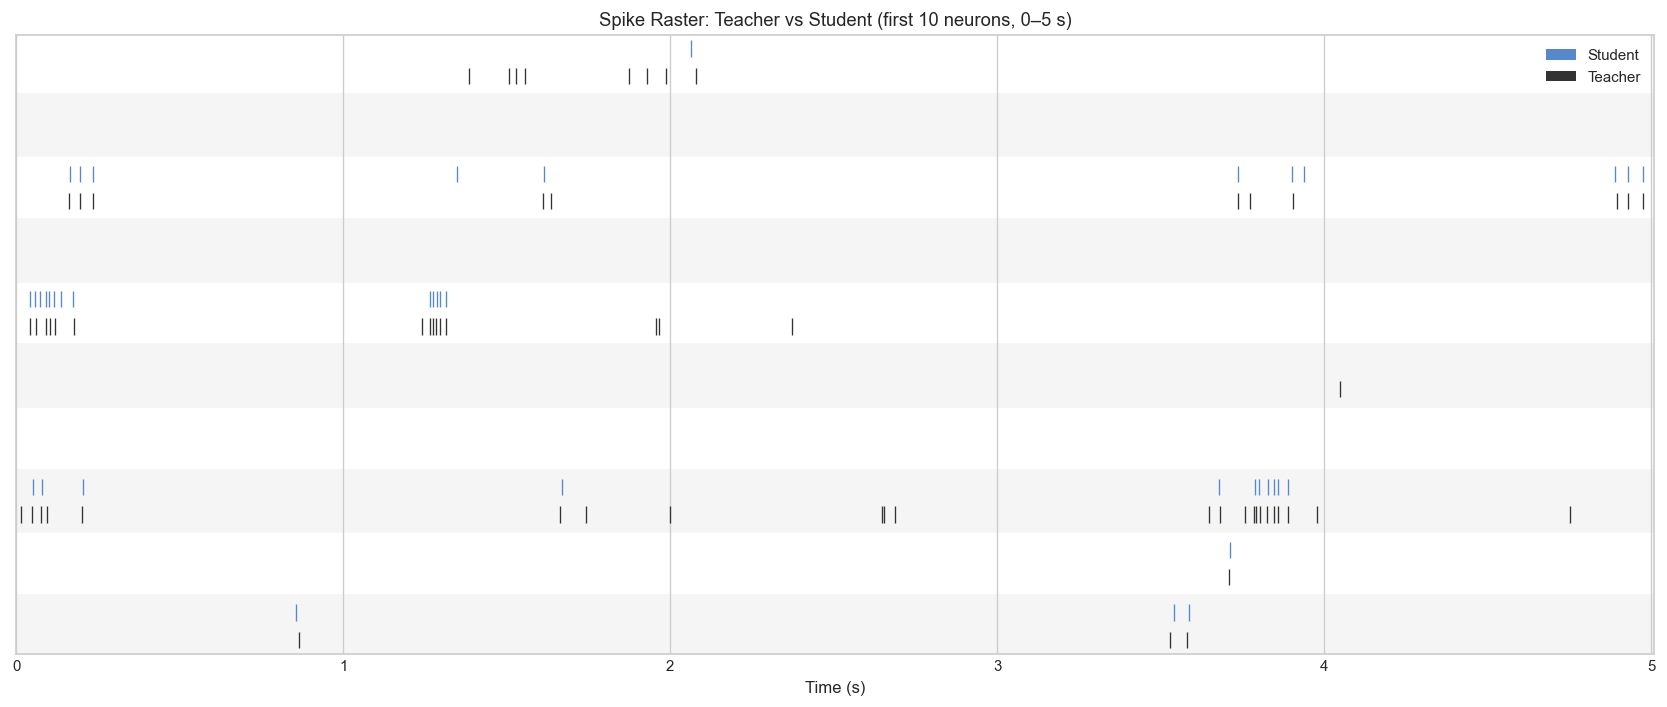

In [13]:
# Spike raster comparison (first 5 seconds)
n_5s = int(5000.0 / inf_dt)
teacher_clip = teacher_spikes[:n_5s, :]
student_clip = student_spikes[:n_5s, :]

interleaved, ct_idx = interleave_spike_trains(
    teacher_clip, student_clip, n_neurons=N_NEURONS_RASTER
)

fig, ax = plt.subplots(figsize=(14, 6))
plot_spike_trains(
    spikes=interleaved,
    dt=inf_dt,
    cell_type_indices=ct_idx,
    cell_type_names=["Teacher", "Student"],
    cell_type_colors={0: TEACHER_COLOR, 1: STUDENT_COLOR},
    n_neurons_plot=2 * N_NEURONS_RASTER,
    n_compared=2,
    fraction=1.0,
    random_seed=None,
    title=f"Spike Raster: Teacher vs Student (first {N_NEURONS_RASTER} neurons, 0\u20135 s)",
    ax=ax,
)
plt.tight_layout()
plt.show()

## Feedforward vs Recurrent Drive

                                    Student       Teacher
FF drive                           937255.0      890225.9
Rec exc drive                      460240.7      488941.0
FF fraction                          0.6707        0.6455
Rec exc fraction                     0.3293        0.3545
Ratio (rec exc / FF)                  0.491         0.549


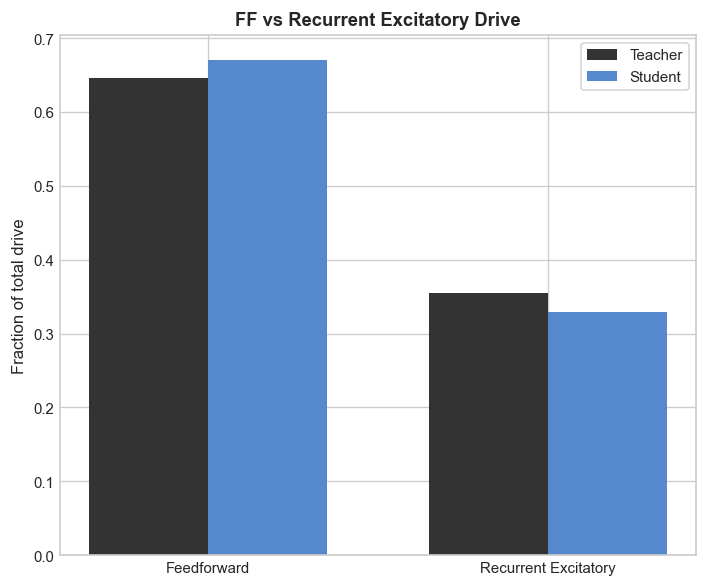

In [14]:
# Feedforward vs Recurrent Excitatory Drive
teacher_rec_w = ns_teacher["recurrent_weights"]  # (n_neurons, n_neurons)

# --- Outgoing weights per source neuron ---
# Teacher FF: feedforward_weights is (source, target)
teacher_ff_outgoing = teacher_ff_w.sum(axis=1)  # (n_feedforward,)
# Teacher rec exc: recurrent_weights is (source, target)
teacher_exc_outgoing = teacher_rec_w[exc_mask, :].sum(axis=1)  # (n_exc,)

# Student FF: learned_ff_w is (source, target)
student_ff_outgoing = learned_ff_w.sum(axis=1)  # (n_feedforward,)
# Student rec: rec_w is (source, target) with SF baked in
student_exc_outgoing = rec_w[exc_mask, :].sum(axis=1)  # (n_exc,)

# --- Accumulate over all zarr batches ---
n_zarr_batches = zarr_root["input_spikes"].shape[0]
chunk_size_acc = 5000  # timesteps per read chunk

teacher_input_counts = np.zeros(n_feedforward, dtype=np.int64)
teacher_output_counts = np.zeros(n_neurons, dtype=np.int64)

n_ts = zarr_root["input_spikes"].shape[1]
for b in range(n_zarr_batches):
    for s in range(0, n_ts, chunk_size_acc):
        teacher_input_counts += zarr_root["input_spikes"][
            b, s : s + chunk_size_acc, :
        ].sum(axis=0)
        teacher_output_counts += zarr_root["output_spikes"][
            b, s : s + chunk_size_acc, :
        ].sum(axis=0)

# Teacher drive
teacher_ff_drive = (teacher_input_counts * teacher_ff_outgoing).sum()
teacher_rec_exc_drive = (teacher_output_counts[exc_mask] * teacher_exc_outgoing).sum()
teacher_total = teacher_ff_drive + teacher_rec_exc_drive

# Student drive (same input spike counts, different weights)
student_ff_drive = (teacher_input_counts * student_ff_outgoing).sum()
student_rec_exc_drive = (teacher_output_counts[exc_mask] * student_exc_outgoing).sum()
student_total = student_ff_drive + student_rec_exc_drive

print(f"{'':30s} {'Student':>12s}  {'Teacher':>12s}")
print(f"{'FF drive':<30s} {student_ff_drive:12.1f}  {teacher_ff_drive:12.1f}")
print(
    f"{'Rec exc drive':<30s} {student_rec_exc_drive:12.1f}  {teacher_rec_exc_drive:12.1f}"
)
print(
    f"{'FF fraction':<30s} {student_ff_drive / student_total:12.4f}  {teacher_ff_drive / teacher_total:12.4f}"
)
print(
    f"{'Rec exc fraction':<30s} {student_rec_exc_drive / student_total:12.4f}  {teacher_rec_exc_drive / teacher_total:12.4f}"
)
print(
    f"{'Ratio (rec exc / FF)':<30s} {student_rec_exc_drive / student_ff_drive:12.3f}  {teacher_rec_exc_drive / teacher_ff_drive:12.3f}"
)

# --- Plot: grouped bar chart (normalised fractions) ---
fig, ax = plt.subplots(figsize=(6, 5))
x = np.arange(2)
width = 0.35
teacher_fracs = [
    teacher_ff_drive / teacher_total,
    teacher_rec_exc_drive / teacher_total,
]
student_fracs = [
    student_ff_drive / student_total,
    student_rec_exc_drive / student_total,
]
ax.bar(x - width / 2, teacher_fracs, width, color=TEACHER_COLOR, label="Teacher")
ax.bar(x + width / 2, student_fracs, width, color=STUDENT_COLOR, label="Student")
ax.set_xticks(x)
ax.set_xticklabels(["Feedforward", "Recurrent Excitatory"])
ax.set_ylabel("Fraction of total drive")
ax.set_title("FF vs Recurrent Excitatory Drive", fontweight="bold")
ax.legend(frameon=True)

plt.tight_layout()
plt.show()

## Membrane Potential Statistics

Run a single trial with voltage tracking for both teacher and student to compare
mean membrane potential and standard deviation by cell type.

In [ ]:
_params = toml.load(PARAMS_FILE)
_sim = StudentSimulationConfig(**_params["simulation"])
_hp = StudentHyperparameters(**_params["hyperparameters"])
_rec_cfg = RecurrentLayerConfig(**_params["recurrent"])
_ff_cfg = FeedforwardLayerConfig(**_params["feedforward"])
chunk_size = _sim.chunk_size

_rec_cell_params = _rec_cfg.get_cell_params()
_ff_cell_params = _ff_cfg.get_cell_params()
_rec_syn_params = _rec_cfg.get_synapse_params()
_ff_syn_params = _ff_cfg.get_synapse_params()
n_ff_cell_types = len(_ff_cell_params)
n_ff_syn_types = len(_ff_syn_params)

# Combined cell/synapse params (FF type + recurrent types with offset IDs)
_combined_cell_params = _ff_cell_params.copy()
for cp in _rec_cell_params:
    ocp = cp.copy()
    ocp["cell_id"] = cp["cell_id"] + n_ff_cell_types
    _combined_cell_params.append(ocp)

_combined_syn_params = _ff_syn_params.copy()
for sp in _rec_syn_params:
    osp = sp.copy()
    osp["cell_id"] = sp["cell_id"] + n_ff_cell_types
    osp["synapse_id"] = sp["synapse_id"] + n_ff_syn_types
    _combined_syn_params.append(osp)

surrgrad = _hp.surrgrad_scale if _hp.surrgrad_scale is not None else 1.0

_rec_names = [c["name"] for c in _rec_cell_params]
_ff_names = [c["name"] for c in _ff_cell_params]
_combined_names = [c["name"] for c in _combined_cell_params]

# --- Build STUDENT model (with voltage tracking) ---
_student_ff_ct = ns_final["feedforward_cell_type_indices"]
_student_ff_conn = ns_final["feedforward_connectivity"]
_student_concat_w = ns_final["feedforward_weights"] * _student_ff_conn.astype(np.float32)
_student_ff_block = _student_concat_w[:n_feedforward, :]
_student_rec_block = _student_concat_w[n_feedforward:, :]

student_projections = make_frozen_chunked_ff_projections(
    rec_weights=_student_rec_block,
    ff_weights=_student_ff_block,
    cell_type_indices=cell_type_indices,
    ff_cell_type_indices=_student_ff_ct[:n_feedforward].astype(np.int64),
    cell_type_names=_rec_names,
    ff_cell_type_names=_ff_names,
    scaling_factors=ns_final["scaling_factors_FF"],
)

student_model = FeedforwardConductanceLIFNetwork(
    dt=dt,
    projections=student_projections,
    cell_type_indices=cell_type_indices,
    cell_type_indices_FF=_student_ff_ct,
    cell_params=_rec_cell_params,
    cell_params_FF=_combined_cell_params,
    synapse_params_FF=_combined_syn_params,
    surrgrad_scale=surrgrad,
    batch_size=1,
    track_variables=True,
)
student_model.to(DEVICE)
student_model.eval()

# --- Build TEACHER model ---
teacher_ff_conn = ns_teacher["feedforward_connectivity"]
teacher_rec_conn = ns_teacher["recurrent_connectivity"]
teacher_ff_cti = ns_teacher["feedforward_cell_type_indices"]
teacher_concat_cti = np.concatenate(
    [teacher_ff_cti, cell_type_indices + n_ff_cell_types]
)
_teacher_ff_block = teacher_ff_w * teacher_ff_conn.astype(np.float32)
_teacher_rec_block = teacher_rec_w * teacher_rec_conn.astype(np.float32)
teacher_sf = np.ones((1 + len(_rec_cell_params), 2), dtype=np.float32)

teacher_projections = make_frozen_chunked_ff_projections(
    rec_weights=_teacher_rec_block,
    ff_weights=_teacher_ff_block,
    cell_type_indices=cell_type_indices,
    ff_cell_type_indices=teacher_ff_cti.astype(np.int64),
    cell_type_names=_rec_names,
    ff_cell_type_names=_ff_names,
    scaling_factors=teacher_sf,
)

teacher_model = FeedforwardConductanceLIFNetwork(
    dt=dt,
    projections=teacher_projections,
    cell_type_indices=cell_type_indices,
    cell_type_indices_FF=teacher_concat_cti,
    cell_params=_rec_cell_params,
    cell_params_FF=_combined_cell_params,
    synapse_params_FF=_combined_syn_params,
    surrgrad_scale=surrgrad,
    batch_size=1,
    track_variables=True,
)
teacher_model.to(DEVICE)
teacher_model.eval()

# --- Run both models: burnin then collect voltages ---
N_BURNIN = 25
N_ANALYSIS = 5
total_chunks = N_BURNIN + N_ANALYSIS
total_ts = total_chunks * chunk_size

teacher_out_all = np.array(zarr_root["output_spikes"][0, :total_ts, :])
teacher_input_all = np.array(zarr_root["input_spikes"][0, :total_ts, :])

student_voltages_list = []
teacher_voltages_list = []

with torch.inference_mode():
    for ci in tqdm(range(total_chunks), desc="voltage inference"):
        t0, t1 = ci * chunk_size, (ci + 1) * chunk_size

        rec_chunk = (
            torch.from_numpy(teacher_out_all[t0:t1].astype(np.float32))
            .unsqueeze(0)
            .to(DEVICE)
        )

        # Student: [mitral spikes (n_feedforward), recurrent spikes (n_neurons)]
        ff_student = (
            torch.from_numpy(teacher_input_all[t0:t1].astype(np.float32))
            .unsqueeze(0)
            .to(DEVICE)
        )
        out_s = student_model(torch.cat([ff_student, rec_chunk], dim=2))

        # Teacher: same inputs
        out_t = teacher_model(torch.cat([ff_student, rec_chunk], dim=2))

        if ci >= N_BURNIN:
            student_voltages_list.append(out_s["voltages"][0].cpu().numpy())
            teacher_voltages_list.append(out_t["voltages"][0].cpu().numpy())

student_voltages = np.concatenate(student_voltages_list, axis=0)
teacher_voltages = np.concatenate(teacher_voltages_list, axis=0)

print(
    f"Collected voltages: {student_voltages.shape[0] * dt / 1000:.1f}s, "
    f"{student_voltages.shape[1]} neurons"
)

                         Mean Vm (mV)       Std Vm (mV)
                      Teacher  Student   Teacher  Student
------------------------------------------------------------------------
Excitatory             -56.54   -54.43      4.50     3.87
Inhibitory             -57.61   -57.07      4.57     4.33


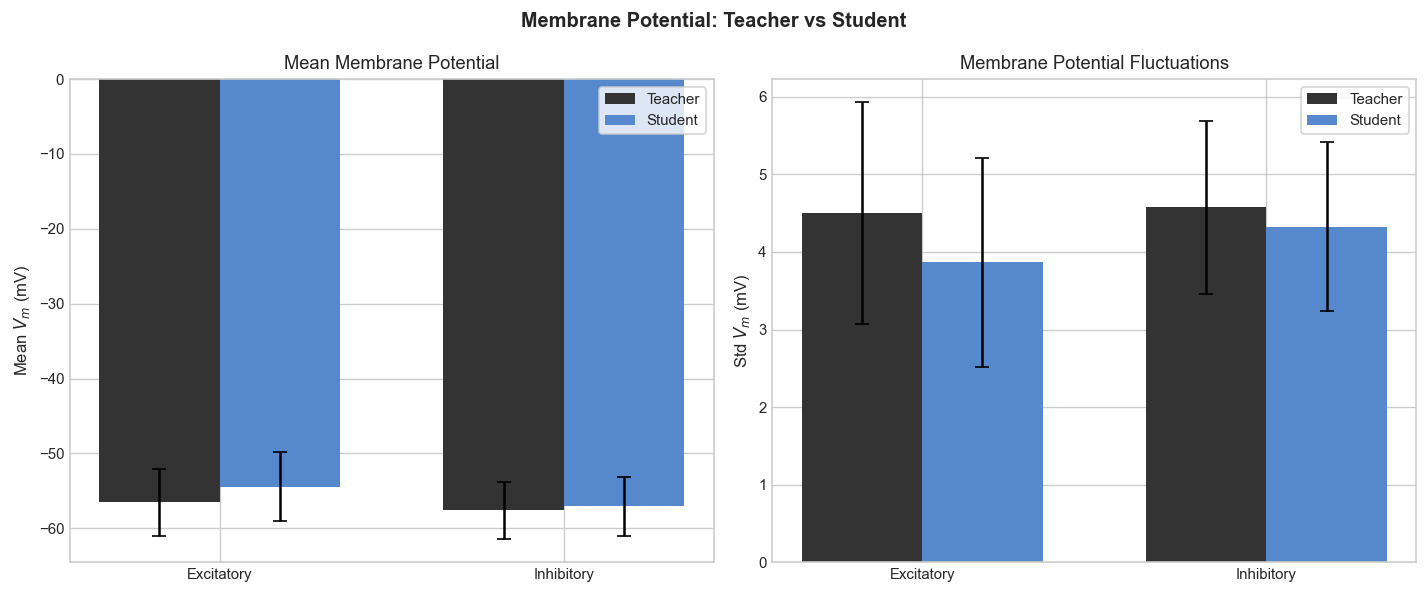

In [16]:
student_v_stats = compute_membrane_potential_by_cell_type(
    student_voltages[np.newaxis], cell_type_indices
)
teacher_v_stats = compute_membrane_potential_by_cell_type(
    teacher_voltages[np.newaxis], cell_type_indices
)

ct_names = {0: "Excitatory", 1: "Inhibitory"}

print(f"{'':20s} {'Mean Vm (mV)':>16s}  {'Std Vm (mV)':>16s}")
print(f"{'':20s} {'Teacher':>8s} {'Student':>8s}  {'Teacher':>8s} {'Student':>8s}")
print("-" * 72)
for ct_idx in [0, 1]:
    t = teacher_v_stats[ct_idx]
    s = student_v_stats[ct_idx]
    print(
        f"{ct_names[ct_idx]:<20s} "
        f"{t['mean_of_means']:8.2f} {s['mean_of_means']:8.2f}  "
        f"{t['mean_of_stds']:8.2f} {s['mean_of_stds']:8.2f}"
    )

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: mean Vm by cell type
ax = axes[0]
x = np.arange(2)
width = 0.35
teacher_means = [teacher_v_stats[ct]["mean_of_means"] for ct in [0, 1]]
student_means = [student_v_stats[ct]["mean_of_means"] for ct in [0, 1]]
teacher_means_err = [teacher_v_stats[ct]["std_of_means"] for ct in [0, 1]]
student_means_err = [student_v_stats[ct]["std_of_means"] for ct in [0, 1]]

ax.bar(
    x - width / 2,
    teacher_means,
    width,
    yerr=teacher_means_err,
    color=TEACHER_COLOR,
    label="Teacher",
    capsize=4,
)
ax.bar(
    x + width / 2,
    student_means,
    width,
    yerr=student_means_err,
    color=STUDENT_COLOR,
    label="Student",
    capsize=4,
)
ax.set_xticks(x)
ax.set_xticklabels(["Excitatory", "Inhibitory"])
ax.set_ylabel("Mean $V_m$ (mV)")
ax.set_title("Mean Membrane Potential")
ax.legend(frameon=True)

# Right: std Vm by cell type
ax = axes[1]
teacher_stds = [teacher_v_stats[ct]["mean_of_stds"] for ct in [0, 1]]
student_stds = [student_v_stats[ct]["mean_of_stds"] for ct in [0, 1]]
teacher_stds_err = [teacher_v_stats[ct]["std_of_stds"] for ct in [0, 1]]
student_stds_err = [student_v_stats[ct]["std_of_stds"] for ct in [0, 1]]

ax.bar(
    x - width / 2,
    teacher_stds,
    width,
    yerr=teacher_stds_err,
    color=TEACHER_COLOR,
    label="Teacher",
    capsize=4,
)
ax.bar(
    x + width / 2,
    student_stds,
    width,
    yerr=student_stds_err,
    color=STUDENT_COLOR,
    label="Student",
    capsize=4,
)
ax.set_xticks(x)
ax.set_xticklabels(["Excitatory", "Inhibitory"])
ax.set_ylabel("Std $V_m$ (mV)")
ax.set_title("Membrane Potential Fluctuations")
ax.legend(frameon=True)

plt.suptitle("Membrane Potential: Teacher vs Student", fontweight="bold")
plt.tight_layout()
plt.show()

## ISI / CV Statistics

Compare the coefficient of variation (CV = std(ISI) / mean(ISI)) between teacher and
student.

                              Mean CV         Median CV
                      Teacher  Student   Teacher  Student
------------------------------------------------------------------------
Excitatory              1.478    1.589     1.396    1.433
Inhibitory              2.065    2.146     1.933    2.009


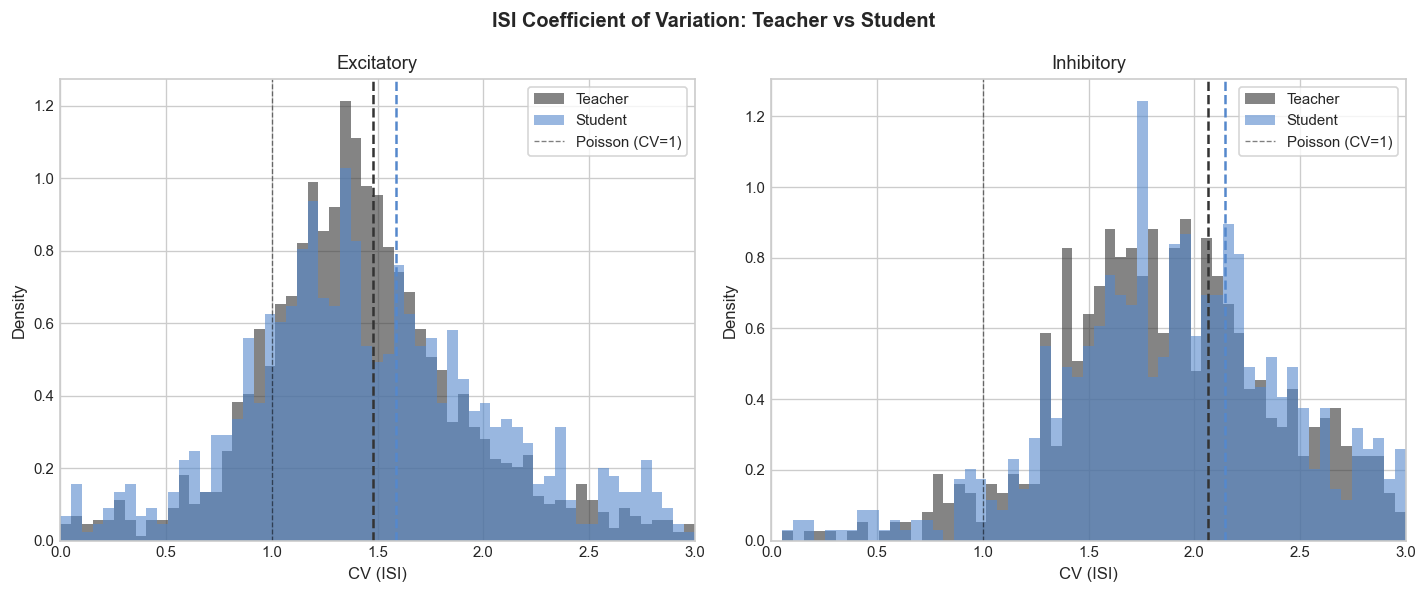

In [17]:
teacher_cv = compute_spike_train_cv(teacher_spikes[np.newaxis], dt=inf_dt * 1e-3)[0]
student_cv = compute_spike_train_cv(student_spikes[np.newaxis], dt=inf_dt * 1e-3)[0]

ct_names = {0: "Excitatory", 1: "Inhibitory"}
print(f"{'':20s} {'Mean CV':>16s}  {'Median CV':>16s}")
print(f"{'':20s} {'Teacher':>8s} {'Student':>8s}  {'Teacher':>8s} {'Student':>8s}")
print("-" * 72)
for ct_idx in [0, 1]:
    mask = cell_type_indices == ct_idx
    t_cv = teacher_cv[mask]
    s_cv = student_cv[mask]
    t_valid = t_cv[~np.isnan(t_cv)]
    s_valid = s_cv[~np.isnan(s_cv)]
    print(
        f"{ct_names[ct_idx]:<20s} "
        f"{np.mean(t_valid):8.3f} {np.mean(s_valid):8.3f}  "
        f"{np.median(t_valid):8.3f} {np.median(s_valid):8.3f}"
    )

# --- Plots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
cv_max = 3.0
bins = np.linspace(0, cv_max, 60)

for ax, ct_idx, ct_name in zip(axes, [0, 1], ["Excitatory", "Inhibitory"]):
    mask = cell_type_indices == ct_idx
    t_cv = teacher_cv[mask]
    s_cv = student_cv[mask]
    t_valid = t_cv[~np.isnan(t_cv)]
    s_valid = s_cv[~np.isnan(s_cv)]

    ax.hist(
        t_valid,
        bins=bins,
        alpha=0.6,
        color=TEACHER_COLOR,
        label="Teacher",
        density=True,
    )
    ax.hist(
        s_valid,
        bins=bins,
        alpha=0.6,
        color=STUDENT_COLOR,
        label="Student",
        density=True,
    )
    ax.axvline(
        1.0, color="k", linewidth=0.8, linestyle="--", alpha=0.5, label="Poisson (CV=1)"
    )
    ax.axvline(np.mean(t_valid), color=TEACHER_COLOR, linewidth=1.5, linestyle="--")
    ax.axvline(np.mean(s_valid), color=STUDENT_COLOR, linewidth=1.5, linestyle="--")
    ax.set_xlabel("CV (ISI)")
    ax.set_ylabel("Density")
    ax.set_title(f"{ct_name}")
    ax.legend(frameon=True, fontsize=9)
    ax.set_xlim(0, cv_max)

plt.suptitle("ISI Coefficient of Variation: Teacher vs Student", fontweight="bold")
plt.tight_layout()
plt.show()

## Pairwise Noise Correlations

Noise correlations measure the moment-to-moment co-variability
between pairs of neurons.

In [18]:
BIN_WIDTH_MS = 50.0
bin_size = int(BIN_WIDTH_MS / inf_dt)
n_time = teacher_spikes.shape[0]
n_bins = n_time // bin_size

teacher_binned = (
    teacher_spikes[: n_bins * bin_size].reshape(n_bins, bin_size, -1).sum(axis=1)
)
student_binned = (
    student_spikes[: n_bins * bin_size].reshape(n_bins, bin_size, -1).sum(axis=1)
)

N_PAIRS = 5000
rng = np.random.default_rng(42)

pair_types = {"E-E": (0, 0), "E-I": (0, 1), "I-I": (1, 1)}
exc_idx = np.where(cell_type_indices == 0)[0]
inh_idx = np.where(cell_type_indices == 1)[0]
pool = {0: exc_idx, 1: inh_idx}

teacher_corrs = {}
student_corrs = {}

for pair_label, (ct_a, ct_b) in pair_types.items():
    idx_a = rng.choice(pool[ct_a], size=N_PAIRS, replace=True)
    idx_b = rng.choice(pool[ct_b], size=N_PAIRS, replace=True)
    same = idx_a == idx_b
    while same.any():
        idx_b[same] = rng.choice(pool[ct_b], size=same.sum(), replace=True)
        same = idx_a == idx_b

    def _pairwise_corr(binned, ia, ib):
        a = binned[:, ia].astype(np.float64)
        b = binned[:, ib].astype(np.float64)
        a -= a.mean(axis=0, keepdims=True)
        b -= b.mean(axis=0, keepdims=True)
        std_a = a.std(axis=0, ddof=1)
        std_b = b.std(axis=0, ddof=1)
        valid = (std_a > 0) & (std_b > 0)
        corr = np.full(len(ia), np.nan)
        if valid.any():
            corr[valid] = (a[:, valid] * b[:, valid]).sum(axis=0) / (
                (n_bins - 1) * std_a[valid] * std_b[valid]
            )
        return corr

    teacher_corrs[pair_label] = _pairwise_corr(teacher_binned, idx_a, idx_b)
    student_corrs[pair_label] = _pairwise_corr(student_binned, idx_a, idx_b)

print(f"Noise correlations (bin={BIN_WIDTH_MS:.0f} ms, {N_PAIRS} pairs per pathway)")
print(
    f"{'Pathway':>8s}  {'Teacher mean':>14s} {'Student mean':>14s}  "
    f"{'Teacher med':>14s} {'Student med':>14s}"
)
print("-" * 72)
for pair_label in pair_types:
    tc = teacher_corrs[pair_label]
    sc = student_corrs[pair_label]
    tv = tc[~np.isnan(tc)]
    sv = sc[~np.isnan(sc)]
    print(
        f"{pair_label:>8s}  "
        f"{np.mean(tv):14.4f} {np.mean(sv):14.4f}  "
        f"{np.median(tv):14.4f} {np.median(sv):14.4f}"
    )

Noise correlations (bin=50 ms, 5000 pairs per pathway)
 Pathway    Teacher mean   Student mean     Teacher med    Student med
------------------------------------------------------------------------
     E-E          0.0001        -0.0047         -0.0176        -0.0154
     E-I         -0.0009         0.0001         -0.0184        -0.0189
     I-I         -0.0006         0.0001         -0.0195        -0.0193


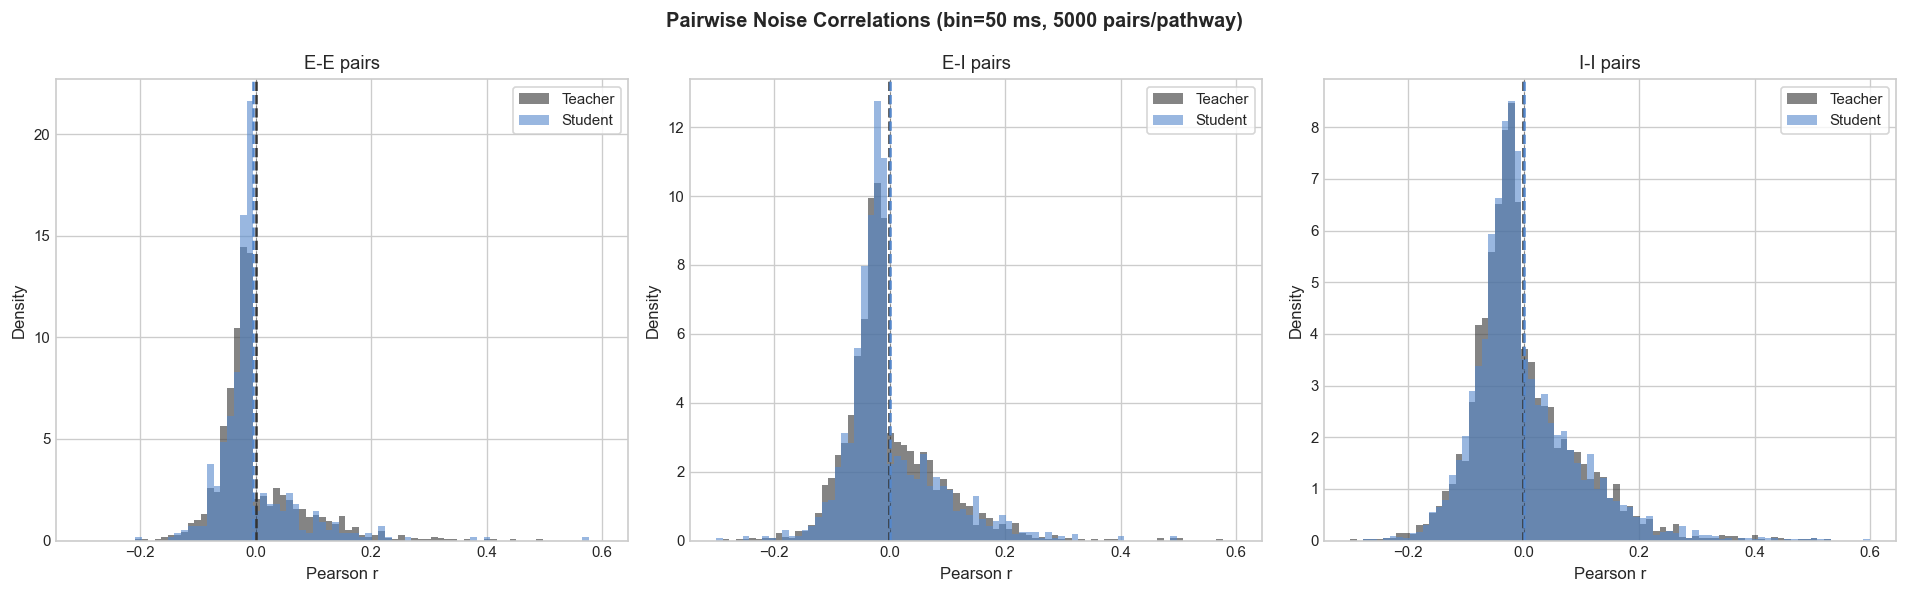

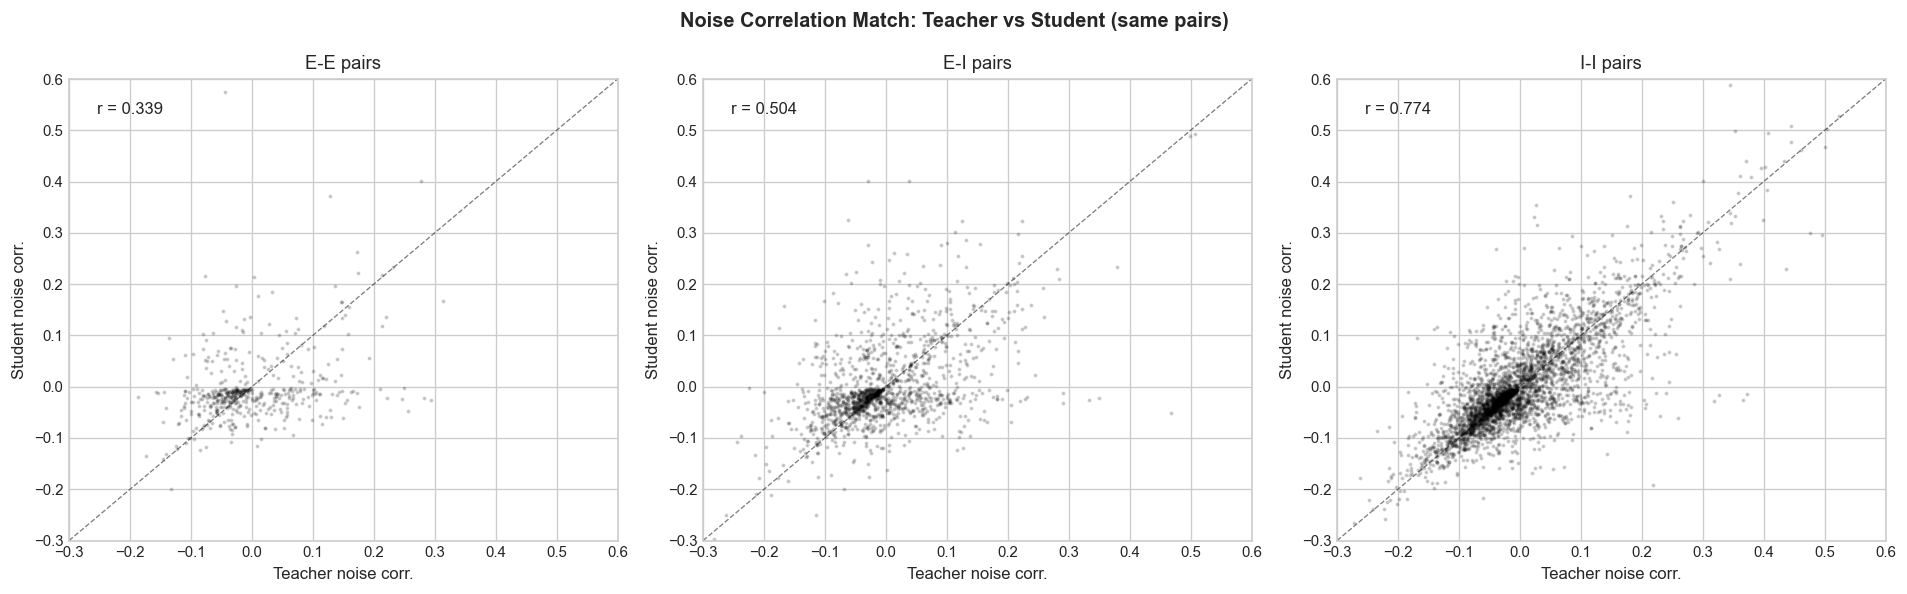

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
corr_bins = np.linspace(-0.3, 0.6, 80)

for ax, pair_label in zip(axes, pair_types):
    tc = teacher_corrs[pair_label]
    sc = student_corrs[pair_label]
    tv = tc[~np.isnan(tc)]
    sv = sc[~np.isnan(sc)]

    ax.hist(
        tv,
        bins=corr_bins,
        alpha=0.6,
        color=TEACHER_COLOR,
        label="Teacher",
        density=True,
    )
    ax.hist(
        sv,
        bins=corr_bins,
        alpha=0.6,
        color=STUDENT_COLOR,
        label="Student",
        density=True,
    )
    ax.axvline(0, color="k", linewidth=0.5, linestyle="--", alpha=0.4)
    ax.axvline(np.mean(tv), color=TEACHER_COLOR, linewidth=1.5, linestyle="--")
    ax.axvline(np.mean(sv), color=STUDENT_COLOR, linewidth=1.5, linestyle="--")
    ax.set_xlabel("Pearson r")
    ax.set_ylabel("Density")
    ax.set_title(f"{pair_label} pairs")
    ax.legend(frameon=True, fontsize=9)

plt.suptitle(
    f"Pairwise Noise Correlations (bin={BIN_WIDTH_MS:.0f} ms, {N_PAIRS} pairs/pathway)",
    fontweight="bold",
)
plt.tight_layout()
plt.show()

# Scatter: teacher vs student noise correlations (same pairs)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, pair_label in zip(axes, pair_types):
    tc = teacher_corrs[pair_label]
    sc = student_corrs[pair_label]
    valid = ~(np.isnan(tc) | np.isnan(sc))
    ax.scatter(tc[valid], sc[valid], s=2, alpha=0.15, color="k", rasterized=True)
    lims = [-0.3, 0.6]
    ax.plot(lims, lims, "k--", linewidth=0.8, alpha=0.5)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel("Teacher noise corr.")
    ax.set_ylabel("Student noise corr.")
    ax.set_title(f"{pair_label} pairs")
    r, _ = pearsonr(tc[valid], sc[valid])
    ax.text(0.05, 0.95, f"r = {r:.3f}", transform=ax.transAxes, va="top", fontsize=10)

plt.suptitle(
    "Noise Correlation Match: Teacher vs Student (same pairs)", fontweight="bold"
)
plt.tight_layout()
plt.show()

## Summary

In [20]:
summary = {
    "Activity R²": f"{r2_act:.4f}",
    f"Fluctuation R² (\u03c3={TAU_MS:.0f} ms)": f"{r2_flu:.4f}",
    "Student FR (exc, Hz)": f"{student_fr[exc_mask].mean():.1f} \u00b1 {student_fr[exc_mask].std():.1f}",
    "Teacher FR (exc, Hz)": f"{teacher_fr[exc_mask].mean():.1f} \u00b1 {teacher_fr[exc_mask].std():.1f}",
    "Student FR (inh, Hz)": f"{student_fr[inh_mask].mean():.1f} \u00b1 {student_fr[inh_mask].std():.1f}",
    "Teacher FR (inh, Hz)": f"{teacher_fr[inh_mask].mean():.1f} \u00b1 {teacher_fr[inh_mask].std():.1f}",
    "FF weight corr (all)": f"{r_all:.4f}",
    "FF weight corr (exc)": f"{r_exc:.4f}",
    "FF weight corr (inh)": f"{r_inh:.4f}",
    "Effective rank (learned)": f"{eff_rank_learned:.2f}",
    "Effective rank (teacher)": f"{eff_rank_teacher:.2f}",
    "Rec exc / FF ratio (student)": f"{student_rec_exc_drive / student_ff_drive:.3f}",
    "Rec exc / FF ratio (teacher)": f"{teacher_rec_exc_drive / teacher_ff_drive:.3f}",
}

for key in available_sf_keys:
    label = dict(SF_PATHWAYS).get(key, key)
    summary[f"SF {label}"] = f"{sf_final[key]:.4f}"

summary_df = pd.DataFrame([{"Metric": k, "Value": v} for k, v in summary.items()])
summary_df

,Metric,Value
0,Activity R²,0.8921
1,Fluctuation R² (σ=50 ms),0.8256
2,"Student FR (exc, Hz)",1.1 ± 4.6
3,"Teacher FR (exc, Hz)",2.3 ± 6.4
4,"Student FR (inh, Hz)",11.3 ± 22.0
5,"Teacher FR (inh, Hz)",12.6 ± 23.9
6,FF weight corr (all),0.0330
7,FF weight corr (exc),0.0265
8,FF weight corr (inh),0.0720
9,Effective rank (learned),1.10
